In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# Data Extraction & Feature Engineering

Load market data and prepare the target variable for next-day return prediction.

In [13]:
# Placeholder ticker, add a list to extract a portfolio
ticker = "AAPL"

df = yf.download(ticker, start="2015-01-01", end="2026-01-01")
df = df[["Close", "Volume"]].copy()

# Temporal split BEFORE feature engineering to prevent data leakage
# Rolling features at test boundary would otherwise include training data
split_idx = int(len(df) * 0.8)
df_train_raw = df.iloc[:split_idx].copy()
df_test_raw = df.iloc[split_idx:].copy()

def add_features(data):
    """Add technical features to a dataframe."""
    data = data.copy()
    # Simple Moving Averages
    data["SMA_20"] = data["Close"].rolling(window=20).mean()
    data["SMA_50"] = data["Close"].rolling(window=50).mean()
    
    # Rolling volatility
    data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))
    data["Volatility_20"] = data["Log_Return"].rolling(window=20).std()
    
    # Daily returns
    data["returns"] = data["Close"].pct_change()
    
    # Target: next-day return
    data["future_return"] = data["Close"].pct_change().shift(-1)
    
    return data

df_train = add_features(df_train_raw)
df_test = add_features(df_test_raw)

# Drop NaN rows (from rolling windows and shift operations)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print(f"Feature columns: {list(df_train.columns)}")
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")
print(f"Train period: {df_train.index[0].date()} to {df_train.index[-1].date()}")
print(f"Test period:  {df_test.index[0].date()} to {df_test.index[-1].date()}")
df_train.head()

[*********************100%***********************]  1 of 1 completed

Feature columns: [('Close', 'AAPL'), ('Volume', 'AAPL'), ('SMA_20', ''), ('SMA_50', ''), ('Log_Return', ''), ('Volatility_20', ''), ('returns', ''), ('future_return', '')]
Train shape: (2162, 8), Test shape: (504, 8)
Train period: 2015-03-16 to 2023-10-13
Test period:  2023-12-27 to 2025-12-30


Price,Close,Volume,SMA_20,SMA_50,Log_Return,Volatility_20,returns,future_return
Ticker,AAPL,AAPL,,,,,,
Date,,,,,,,,
2015-03-16,27.758125,143497200,28.371492,26.537694,0.010944,0.013728,0.011004,0.016727
2015-03-17,28.222433,204092400,28.362717,26.618291,0.016589,0.014205,0.016727,0.011256
2015-03-18,28.540110,261083600,28.359941,26.718872,0.011193,0.014350,0.011256,-0.007551
2015-03-19,28.324612,183238000,28.349388,26.815098,-0.007579,0.014442,-0.007551,-0.012549
2015-03-20,27.969177,274780400,28.309400,26.897623,-0.012628,0.014544,-0.012549,0.010405


# Visualize Price Data

Inspect the closing-price history before moving into model preparation.

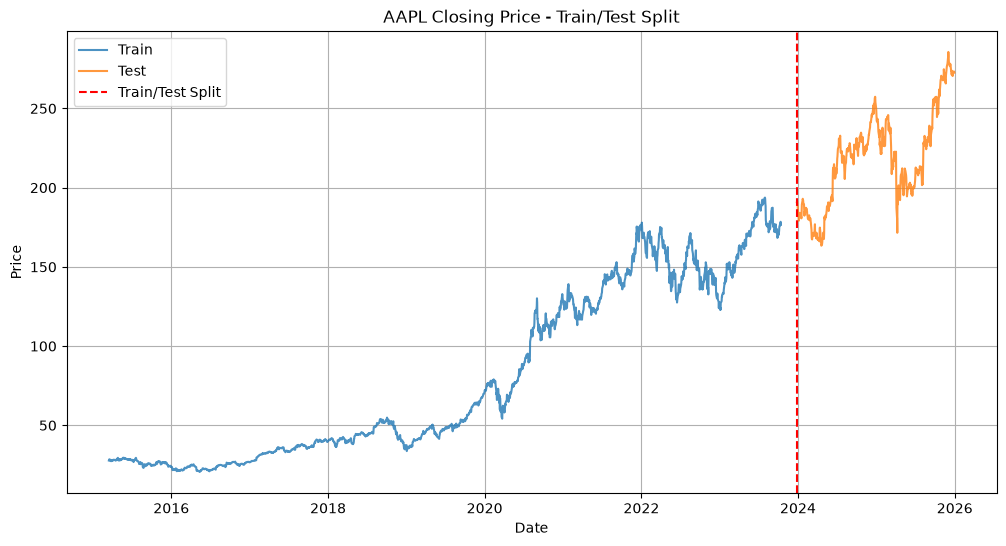

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_train.index, df_train["Close"], label="Train", alpha=0.8)
ax.plot(df_test.index, df_test["Close"], label="Test", alpha=0.8)
ax.axvline(df_test.index[0], color="red", linestyle="--", label="Train/Test Split")
ax.set_title(f"{ticker} Closing Price - Train/Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.grid(True)
plt.show()

# Scale Data, Create Validation Split & Build Sequences

Create a validation set from training data (test set remains untouched during training), fit scalers on train only, and convert to rolling windows for the CNN.

In [15]:
# Feature & target columns
feature_cols = ["Close", "SMA_20", "SMA_50", "Volatility_20", "returns"]
target_col = "future_return"

# Create validation split from training data (20% of train -> validation)
# Test set remains completely untouched during training
val_split_idx = int(len(df_train) * 0.8)
df_train_split = df_train.iloc[:val_split_idx]
df_val = df_train.iloc[val_split_idx:]

print(f"Train split: {len(df_train_split)} rows ({df_train_split.index[0].date()} to {df_train_split.index[-1].date()})")
print(f"Validation:  {len(df_val)} rows ({df_val.index[0].date()} to {df_val.index[-1].date()})")
print(f"Test (held out): {len(df_test)} rows ({df_test.index[0].date()} to {df_test.index[-1].date()})")

# Fit scalers on train split only
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))

train_features_scaled = feature_scaler.fit_transform(df_train_split[feature_cols])
val_features_scaled = feature_scaler.transform(df_val[feature_cols])
test_features_scaled = feature_scaler.transform(df_test[feature_cols])

train_target_scaled = target_scaler.fit_transform(df_train_split[[target_col]])
val_target_scaled = target_scaler.transform(df_val[[target_col]])
test_target_scaled = target_scaler.transform(df_test[[target_col]])

# Build rolling sequences
sequence_length = 60
n_features = len(feature_cols)

def build_sequences(features, targets, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len:i, :])
        y.append(targets[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = build_sequences(train_features_scaled, train_target_scaled, sequence_length)
X_val, y_val = build_sequences(val_features_scaled, val_target_scaled, sequence_length)
X_test, y_test = build_sequences(test_features_scaled, test_target_scaled, sequence_length)

print(f"\nSequence shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Train split: 1729 rows (2015-03-16 to 2022-01-24)
Validation:  433 rows (2022-01-25 to 2023-10-13)
Test (held out): 504 rows (2023-12-27 to 2025-12-30)

Sequence shapes:
X_train: (1669, 60, 5), y_train: (1669,)
X_val:   (373, 60, 5), y_val:   (373,)
X_test:  (444, 60, 5), y_test:  (444,)


# Build & Train The CNN Feature Extractor

Train a 1D CNN on the sequence windows, then reuse its intermediate representation as a learned feature space.

In [16]:
cnn_input = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = Conv1D(64, kernel_size=3, activation="relu", padding="causal")(cnn_input)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv1D(64, kernel_size=3, activation="relu", padding="causal")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

cnn_features = GlobalAveragePooling1D(name="cnn_features")(x)
cnn_output = Dense(1)(cnn_features)

cnn_model = Model(inputs=cnn_input, outputs=cnn_output)
cnn_model.compile(optimizer="adam", loss="mean_squared_error")
cnn_model.summary()

# Use VALIDATION set for early stopping, NOT test set (prevents data leakage)
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),  # Validation, NOT test
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 60, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_features                    │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,697 (53.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1145 - val_loss: 0.0384
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0269 - val_loss: 0.0323
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0254 - val_loss: 0.2712
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0252 - val_loss: 0.3657
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0174 - val_loss: 0.0785
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0153 - val_loss: 0.1058
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0142 - val_loss: 0.0222
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0134 - val_loss: 0.1094
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124 - val_loss: 0.8578
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0122 - val_loss: 0.4333
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0111 - val_loss: 0.0162
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0109 - val_lo

# Evaluate CNN Predictions

Evaluate the CNN model predictions on the held-out test set.

In [17]:
# CNN predictions on test set
cnn_pred_scaled = cnn_model.predict(X_test, verbose=0)
cnn_pred_returns = target_scaler.inverse_transform(cnn_pred_scaled).flatten()
actual_returns = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# CNN metrics
mae = mean_absolute_error(actual_returns, cnn_pred_returns)
rmse = np.sqrt(mean_squared_error(actual_returns, cnn_pred_returns))
direction_acc = np.mean(np.sign(cnn_pred_returns) == np.sign(actual_returns))

print("=" * 50)
print("CNN PREDICTIONS")
print("=" * 50)
print(f"MAE  (next-day return) : {mae:.6f}")
print(f"RMSE (next-day return) : {rmse:.6f}")
print(f"Directional Accuracy   : {direction_acc:.2%}")
print("=" * 50)

# Use CNN predictions for downstream analysis
pred_returns = cnn_pred_returns

CNN PREDICTIONS
MAE  (next-day return) : 0.066640
RMSE (next-day return) : 0.076908
Directional Accuracy   : 54.28%


# Visualize CNN Predictions

Compare CNN predictions against actual next-day returns.

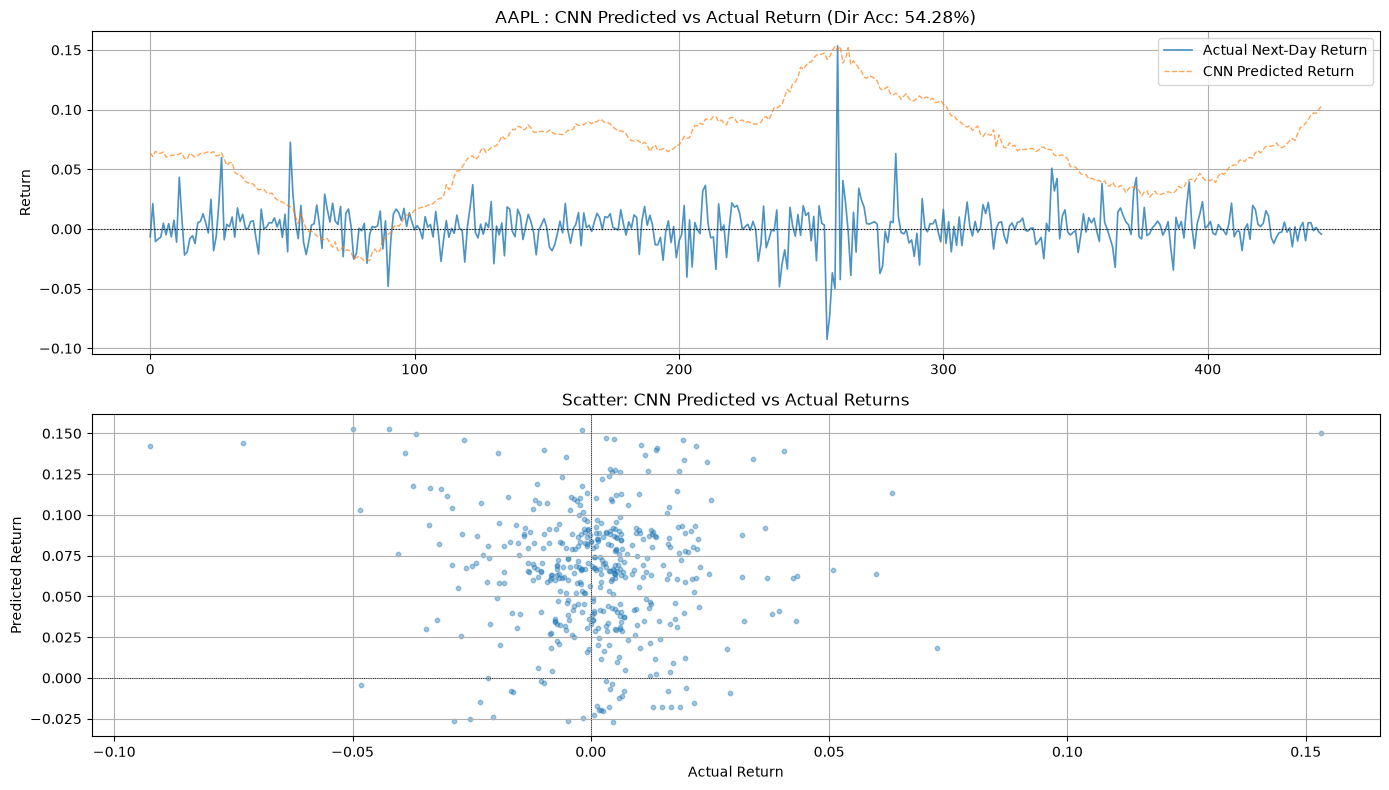

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# CNN predictions vs actual
axes[0].plot(actual_returns, label="Actual Next-Day Return", linewidth=1.2, alpha=0.8)
axes[0].plot(cnn_pred_returns, label="CNN Predicted Return", linestyle="--", linewidth=1, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[0].set_title(f"{ticker} : CNN Predicted vs Actual Return (Dir Acc: {direction_acc:.2%})")
axes[0].set_ylabel("Return")
axes[0].legend(); axes[0].grid(True)

# Scatter plot
axes[1].scatter(actual_returns, cnn_pred_returns, alpha=0.4, s=10)
axes[1].axhline(0, color="black", linewidth=0.6, linestyle=":")
axes[1].axvline(0, color="black", linewidth=0.6, linestyle=":")
axes[1].set_xlabel("Actual Return")
axes[1].set_ylabel("Predicted Return")
axes[1].set_title("Scatter: CNN Predicted vs Actual Returns")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Trading Strategy

Convert the prediction series into a simple long-only strategy and compare it with buy-and-hold performance.

In [19]:
# Align predictions with dates
# Test sequences start at row `sequence_length` inside df_test
test_dates = df_test.index[sequence_length:]

strategy_df = pd.DataFrame(index=test_dates)
strategy_df["Close"] = df_test["Close"].values[sequence_length:]
strategy_df["actual_return"] = actual_returns
strategy_df["pred_return"] = pred_returns

# Signal generation: Long (+1) when prediction is positive, Flat (0) otherwise
strategy_df["signal"] = np.where(strategy_df["pred_return"] > 0, 1, 0)

# Shift by 1: prediction at close of day t -> position entered at open of day t+1
# This avoids look-ahead bias in the backtest
strategy_df["position"] = strategy_df["signal"].shift(1).fillna(0)

# Market returns & strategy returns
strategy_df["market_return"] = strategy_df["Close"].pct_change().fillna(0)

# Estimate transaction costs (5 bps per trade)
cost_per_trade = 0.0005
strategy_df["trades"] = strategy_df["position"].diff().abs().fillna(0)
strategy_df["transaction_cost"] = strategy_df["trades"] * cost_per_trade

# Strategy returns (gross and net of costs)
strategy_df["strategy_return_gross"] = strategy_df["position"] * strategy_df["market_return"]
strategy_df["strategy_return"] = strategy_df["strategy_return_gross"] - strategy_df["transaction_cost"]

# Cumulative returns
strategy_df["cumulative_market"] = (1 + strategy_df["market_return"]).cumprod()
strategy_df["cumulative_strategy"] = (1 + strategy_df["strategy_return"]).cumprod()

# Performance metrics
total_return_strategy = strategy_df["cumulative_strategy"].iloc[-1] - 1
total_return_market = strategy_df["cumulative_market"].iloc[-1] - 1

# Sharpe ratio with risk-free rate (assume 4% annual)
risk_free_daily = 0.04 / 252
excess_returns = strategy_df["strategy_return"] - risk_free_daily
sharpe = (excess_returns.mean() / (excess_returns.std() + 1e-9)) * np.sqrt(252)

# Max drawdown
cum = strategy_df["cumulative_strategy"]
rolling_max = cum.cummax()
drawdown = (cum - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Win rate (days with positive return when in position)
in_market = strategy_df["position"] == 1
win_rate = (strategy_df.loc[in_market, "strategy_return"] > 0).mean() if in_market.sum() > 0 else 0

# Trade statistics
total_trades = strategy_df["trades"].sum()
total_cost = strategy_df["transaction_cost"].sum()

print("=" * 50)
print("TRADING STRATEGY PERFORMANCE")
print("=" * 50)
print(f"Strategy Total Return  : {total_return_strategy:.2%}")
print(f"Market Total Return    : {total_return_market:.2%}")
print(f"Sharpe Ratio (rf=4%)   : {sharpe:.4f}")
print(f"Max Drawdown           : {max_drawdown:.2%}")
print(f"Win Rate (in market)   : {win_rate:.2%}")
print(f"\nTotal Trades           : {total_trades:.0f}")
print(f"Total Transaction Cost : {total_cost:.4f} ({total_cost*100:.2f}%)")
print("=" * 50)

TRADING STRATEGY PERFORMANCE
Strategy Total Return  : 66.38%
Market Total Return    : 61.14%
Sharpe Ratio (rf=4%)   : 1.0327
Max Drawdown           : -33.36%
Win Rate (in market)   : 55.85%

Total Trades           : 3
Total Transaction Cost : 0.0015 (0.15%)


# Visualize Strategy performance

Plot the prediction trace, the generated positions, and cumulative performance against buy-and-hold.

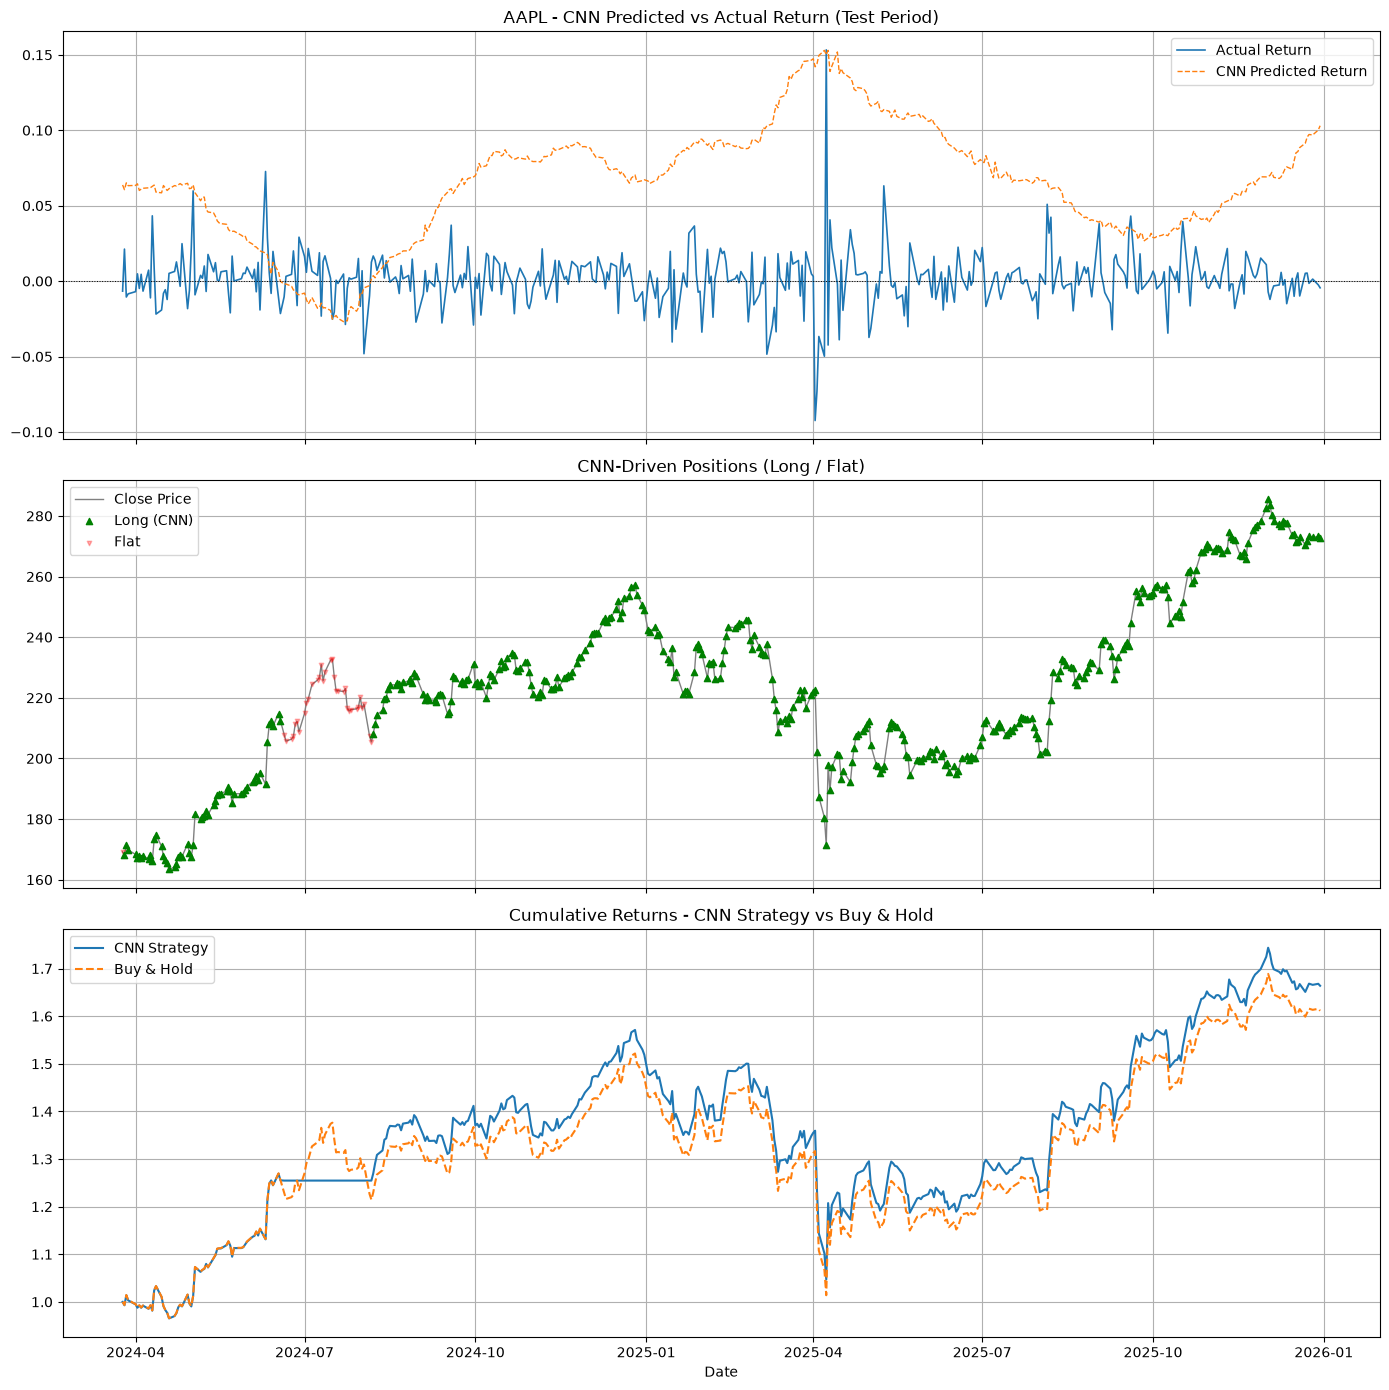

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

# CNN predicted vs actual return
axes[0].plot(strategy_df.index, strategy_df["actual_return"], label="Actual Return", linewidth=1.2)
axes[0].plot(strategy_df.index, strategy_df["pred_return"], label="CNN Predicted Return", linestyle="--", linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.7, linestyle=":")
axes[0].set_title(f"{ticker} - CNN Predicted vs Actual Return (Test Period)")
axes[0].legend(); axes[0].grid(True)

# Model-driven positions overlaid on closing price
axes[1].plot(strategy_df.index, strategy_df["Close"], label="Close Price", linewidth=1, color="grey")
long_pts = strategy_df[strategy_df["position"] == 1]
flat_pts = strategy_df[strategy_df["position"] == 0]
axes[1].scatter(long_pts.index, long_pts["Close"], marker="^", color="green", s=20, label="Long (CNN)", zorder=5)
axes[1].scatter(flat_pts.index, flat_pts["Close"], marker="v", color="red", s=10, alpha=0.3, label="Flat", zorder=4)
axes[1].set_title("CNN-Driven Positions (Long / Flat)")
axes[1].legend(); axes[1].grid(True)

# Cumulative returns
axes[2].plot(strategy_df.index, strategy_df["cumulative_strategy"], label="CNN Strategy", linewidth=1.5)
axes[2].plot(strategy_df.index, strategy_df["cumulative_market"], label="Buy & Hold", linewidth=1.5, linestyle="--")
axes[2].set_title("Cumulative Returns - CNN Strategy vs Buy & Hold")
axes[2].set_xlabel("Date")
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

# Export Data

Save the actual and predicted returns for downstream analysis or comparison with other models.

In [21]:
results = pd.DataFrame({
    "Actual": actual_returns.flatten(),
    "Predicted": pred_returns.flatten()
})

results.to_csv("cnn_portfolio_forecasts.csv", index=False)

results.head()

,Actual,Predicted
0,-0.006672,0.063733
1,0.021212,0.060617
2,-0.010559,0.065127
3,-0.008456,0.063256
4,-0.006999,0.063430
